<div class="alert alert-block alert-danger">
    <b> UNTANGLING THE CYTOSKELETON: A MODEL TO DESCRIBE CYTOSKELETAL ORGANIZATION - CODE</b> 
    
 **4 - PROCESSING**
    
**Author**: Diogo Fróis Vieira
</div>

<div class="alert alert-block alert-info">
    
 **IMPORTS**
    
</div>

In [1]:
import os
import sys
sys.path.append(os.path.abspath('..'))
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import matplotlib.cm as pltc
import matplotlib.colors as colors
import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed, interact_manual
from IPython.display import display
from packageCYSK.importing import *
from packageCYSK.preprocessingCYTO import *
from packageCYSK.processing import *
from packageCYSK.visualization import *
from packageCYSK.processing_LSF import *
from packageCYSK.processing_DCF import *
from packageCYSK.processing_CNF import *

print('📚 All libraries successfully imported 📚')

📚 All libraries successfully imported 📚


<div class="alert alert-block alert-info">
    
 **DIRECTORIES**
    
</div>

In [2]:
# Define dataset folder.
folder      = os.getcwd() + "\\data"

# Import images from CYTO, NUCL and RGB folders.
options     = ["CYTO","NUCL"]

# Dictionary with keys "CYTO", "NUCL", "RGB".
data = init_import(folder,options)

ROIs = pd.read_pickle(folder + "\\ROIs\\ROIs_HPA_TEST2.pkl")

# Import preprocessed products
data['CYTO_PRE'] = pd.read_pickle(folder + "\\CYTO_PRE\\CYTO_PRE_FINAL.pkl")
data['NUCL_PRE'] = pd.read_pickle(folder + "\\NUCL_PRE\\NUCL_PRE.pkl")

ResultsDF = pd.read_pickle(folder + "\\ResultsDF_TEST_FINAL.pkl")

Voxel depth (Z-spacing) could not be determined. Set to 1 (default).
>>> [CYTO] added.
Voxel depth (Z-spacing) could not be determined. Set to 1 (default).
>>> [NUCL] added.


In [3]:
ResultsDF

,Path,Name,Img Index,Label,Image Size,Resolution,Mask,Mask Filled,Skeleton,Patch:Deconvoluted Cyto,Patch:Cyto Mask,Patch:Skeleton,Offset,Lines,Nucleus Centroid,Nucleus Contour
0,C:\Users\diogo\OneDrive - Universidade de Lisb...,Cells_HPA_Cells_abc.tif,HPA,Cells,"(2048, 2048)","(1, 0.08, 0.08)","([163, 164, 164, 164, 164, 164, 165, 165, 165,...","([189, 189, 189, 189, 190, 190, 190, 190, 190,...","([192, 193, 194, 195, 196, 197, 198, 199, 200,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[163, 164, 164, 164, 164, 164, 165, 165, 165,...","[((127.087, 192.528), (133.682, 268.763)), ((1...","(525.09, 189.429)","[[189, 423], [188, 424], [187, 424], [186, 424..."


<div class="alert alert-block alert-info">
    
 **INSTRUCTIONS**
    
</div>

**OPTION 1:** Select a cell from the ROIs dataframe and individually process it

**OPTION 2:** Process the whole ROIs dataset and prepare for feature extraction

Then, visualize the results by selecting the desired cell. Save ```ResultsDF``` to apply feature extraction on the next notebook.

<div class="alert alert-block alert-info">
    
 **SELECT CELL**
    
</div>

In [4]:
def dropdown_cell_eventhandler(change):
    global cell
    cell = dropdown_image.value
    lab = ROIs['Label'][dropdown_image.value]
    print('Cell ' + str(cell) + ' (' + str(lab) +') selected.')

dropdown_image = widgets.Dropdown(description =  'Select Cell:' , options = ['...'] + list(ROIs.index))
dropdown_image.observe(dropdown_cell_eventhandler, names='value')
display(dropdown_image)

Dropdown(description='Select Cell:', options=('...', 0), value='...')

Cell 0 (Cells) selected.


<div class="alert alert-block alert-info">
    
 **PROCESS CELL**
    
</div>

## TO DO

- curar mask da célula (? ja tenho a texture?)
- tornar processing_cell possível sem NUCL à mistura, para se eliminar este processing_cell_hpa

In [5]:
def processing_cell_hpa(rowROI,data,LSFparams):
    """
    Process a specific cell given its ROI.
       - ```rowROI```: dataframe with specific ROI corresponding to a cell
       - ```data```: data dict with the following keys:
                           - CYTO and CYTO_PRE
                           - NUCL and NUCL_PRE
       - ```LSFparams```: ALR threshold 
    
    """
    from tifffile import imread,imwrite
    global img_id,x_,y_
    
    # Useful variables:
    img_id  = rowROI['Index']
    name    = rowROI['Name']
    label   = rowROI['Label']
    mask    = retrieve_mask(rowROI['ROImask'],rowROI['Image Size']) # 1040 x 1388
    
    
    # Isolate deconvoluted cytoskeleton and nuclei within mask and normalize intensities
    cdeconv = data['CYTO']['Image'][img_id]
    ndeconv = data['NUCL']['Image'][img_id]

    cyto        = mask * cdeconv
    cyto_norm   = (cyto-np.min(cyto))/(np.max(cyto)-np.min(cyto)) #cyto_norm   = mask * (cdeconv / np.max(cdeconv)) / np.max(cyto) #aux_f
    ndeconv         = mask * ndeconv
    ndeconv_norm   = (ndeconv-np.min(ndeconv))/(np.max(ndeconv)-np.min(ndeconv)) #ndeconv_norm   = mask * (ndeconv / np.max(ndeconv)) / np.max(ndeconv)

    # Isolate skeleton within mask
    esqueleto       = data['CYTO_PRE']['Skeleton'][img_id] * 1
    mesqueleto      = mask * esqueleto                              # aux_
    
    # Isolate skeleton with intensities within mask
    mesqueleto_int  = mesqueleto * cdeconv
    mesqueleto_norm = mesqueleto * cyto_norm
    
    # Get x and y coordinates within mask and get patches
    x_,y_   = np.where((mask*1) != 0) # resolver aqui para fazer um retangulo de branco com pad2 para as figuras ficarem direitas?
    patch_sk   = mesqueleto[min(x_):max(x_),min(y_):max(y_)]
    patch_cy   = cyto_norm[min(x_):max(x_),min(y_):max(y_)]
    patch_tex_ = data['CYTO_PRE']['Texture'][img_id] * mask
    patch_tex  = patch_tex_[min(x_):max(x_),min(y_):max(y_)]
    patch_nc   = ndeconv_norm[min(x_):max(x_),min(y_):max(y_)]
    
    # Get cell's centroid
    centroid_id,centroid = ROI_centroid(data,img_id,[x_,y_])
    
    
    # NUCLEUS
#     aux_n = np.zeros_like(ndeconv)
#     rownuc = data['NUCL_PRE'].loc[centroid_id]

#     #a = list(zip(rownuc['Nucleus Mask'][0],rownuc['Nucleus Mask'][1]))
#     aux_n[rownuc['Nucleus Mask'][0],rownuc['Nucleus Mask'][1]] = 1

#     aux_n_ = aux_n * ndeconv_norm

    try:
        contourr = data['NUCL_PRE'].loc[centroid_id]['Contour'] 
        cr       = contourr.reshape((contourr.shape[0],contourr.shape[2]))
    except:
        contourr = data['NUCL_PRE'].loc[centroid_id]['Contour'][0]
        cr       = contourr.reshape((contourr.shape[0],contourr.shape[2]))
    
    
    ### DECONVOLUTED CELL FEATURES (DCFs)
#     # CYTO
#     feats_all                    = processingDCF(cyto_norm,(cyto_norm != 0)*1, mesqueleto_norm,features,data['CYTO'].loc[img_id]['Resolution'],data['CYTO'].loc[img_id]['Path'])
#     feats_labels_, feats_values_ = feats_all.print_features(print_values = False)
#     feats_labels_, feats_values_ = remove_not1D(feats_labels_,feats_values_)
#     feats_labels_                = ['DCF:' + ftf for ftf in feats_labels_]
    
#     # NUCL
#     feats_all_n                      = processingDCF(ndeconv_norm,(ndeconv_norm != 0)*1,'None',features,data['NUCL'].loc[img_id]['Resolution'],data['NUCL'].loc[img_id]['Path'])
#     feats_labels_n_, feats_values_n_ = feats_all_n.print_features(print_values = False)
#     feats_labels_n_, feats_values_n_ = remove_not1D(feats_labels_n_,feats_values_n_)
#     feats_labels_n_                  = ['DNF:' + ftn for ftn in feats_labels_n_]
    
    
    ### LINE SEGMENT FEATURES (LSFs)
    #lines, median_points, cytocenter, LSFs = line_segment_features(features,mesqueleto,img_id,mask,patch,(x_,y_),centroid,False)
    lines = skeleton_to_lines(mesqueleto,res_thr = LSFparams['res_thr'])

    ### CYTOSKELETON NETWORK FEATURES (CNFs)
    global int_ske, graph, graph_res, shollhist, cncd, pxlcount
    #graph,CNFs,shollhist = cyto_graph_features(mesqueleto_norm,features,[x_,y_],[aux_n_,centroid,cr],mask,False) #int_ske         = (mesqueleto * aux_f) / np.max(aux_f) 
    #graph       = Skeleton(skeleton_image=().astype(float)) 
    
    ### EXPORT TO SOAX
    #imwrite(os.path.join(os.getcwd(), 'tosoax1.tiff'), (patch_sk * patch_cy * np.max(patch_cy)* 255).astype(np.bool),photometric='minisblack')
    
    
    # Add to DataFrame
    global ResultsDF,new
    if 'ResultsDF' not in globals():
        ResultsDF = pd.DataFrame(columns = ['Path',
                                            'Name',
                                            'Img Index', 
                                            'Label',
                                            'Image Size',
                                            'Resolution', 
                                            'Mask',
                                            'Mask Filled',
                                            'Skeleton', 
                                            'Patch:Deconvoluted Cyto', 
                                            'Patch:Cyto Mask',
                                            'Patch:Skeleton', 
                                            'Offset', 
                                            'Lines',
                                            'Nucleus Centroid',
                                            'Nucleus Contour'])

    new       = pd.Series([data['CYTO']['Path'][img_id], 
                          name,
                          img_id,
                          label,
                          rowROI['Image Size'],
                          data['CYTO']['Resolution'][img_id],
                          rowROI['ROImask'],
                          np.where((data['CYTO_PRE'].loc[img_id]['Mask Filled']*1) != 0),
                          np.where((mesqueleto*1) != 0),
                          patch_cy, 
                          patch_tex,
                          patch_sk, #era mesqueleto 
                          [x_,y_],
                          
                          lines,
                          centroid,
                          cr], index=ResultsDF.columns)


    ResultsDF = pd.concat([ResultsDF,new.to_frame().T],axis=0,ignore_index=True)
         
    return ResultsDF

ResultsDF = processing_cell_hpa(rowROI           = ROIs.loc[cell],
                                data             = data,
                                LSFparams        = {'res_thr': 4})

ResultsDF

symmetric branch  True [[604. 158.]
 [605. 159.]
 [605. 160.]
 [604. 161.]]


,Path,Name,Img Index,Label,Image Size,Resolution,Mask,Mask Filled,Skeleton,Patch:Deconvoluted Cyto,Patch:Cyto Mask,Patch:Skeleton,Offset,Lines,Nucleus Centroid,Nucleus Contour
0,C:\Users\diogo\OneDrive - Universidade de Lisb...,Cells_HPA_Cells_abc.tif,HPA,Cells,"(2048, 2048)","(1, 0.08, 0.08)","([163, 164, 164, 164, 164, 164, 165, 165, 165,...","([189, 189, 189, 189, 190, 190, 190, 190, 190,...","([192, 193, 194, 195, 196, 197, 198, 199, 200,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[163, 164, 164, 164, 164, 164, 165, 165, 165,...","[((127.087, 192.528), (133.682, 268.763)), ((1...","(525.09, 189.429)","[[189, 423], [188, 424], [187, 424], [186, 424..."


In [5]:
ResultsDF

,Path,Name,Img Index,Label,Image Size,Resolution,Mask,Mask Filled,Skeleton,Patch:Deconvoluted Cyto,Patch:Cyto Mask,Patch:Skeleton,Offset,Lines
0,C:\Users\diogo\OneDrive - Universidade de Lisb...,Cells_HPA_Cells_abc.tif,HPA,Cells,"(2048, 2048)","(1, 0.08, 0.08)","([163, 164, 164, 164, 164, 164, 165, 165, 165,...","([189, 189, 189, 189, 190, 190, 190, 190, 190,...","([192, 193, 194, 195, 196, 197, 198, 199, 200,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[163, 164, 164, 164, 164, 164, 165, 165, 165,...","[((127.087, 192.528), (133.682, 268.763)), ((1..."


<div class="alert alert-block alert-info">
    
 **PROCESSING DATAFRAME**
    
</div>

In [5]:
ResultsDF = df_processing_cell(data   = data,
                               ROIsDF = ROIs,
                               params = {'res_thr': 4 })

>>> Progress: 0.0% 0
>>> Progress: 50.0% 1


<div class="alert alert-block alert-info">
    
 **PLOT PROCESSED CELLS**
    
</div>

In [8]:
data['NUCL_PRE']

,Path,Img Index,Label,Label 2,Label ID,Image Size,Nucleus Mask,Centroid,Contour
0,C:\Users\diogo\OneDrive - Universidade de Lisb...,HPA,Cells,abc.tif,1,"(2048, 2048)","[[67, 67, 68, 68, 68, 68, 68, 68, 68, 68, 68, ...","(152.409, 1778.906)","[[[1839, 67]], [[1838, 68]], [[1837, 68]], [[1..."
1,C:\Users\diogo\OneDrive - Universidade de Lisb...,HPA,Cells,abc.tif,2,"(2048, 2048)","[[154, 154, 154, 154, 154, 154, 154, 154, 154,...","(233.328, 879.191)","[[[821, 154]], [[820, 155]], [[819, 156]], [[8..."
2,C:\Users\diogo\OneDrive - Universidade de Lisb...,HPA,Cells,abc.tif,3,"(2048, 2048)","[[225, 225, 225, 225, 225, 225, 225, 225, 226,...","(315.514, 542.272)","[[[504, 225]], [[503, 226]], [[502, 226]], [[5..."
3,C:\Users\diogo\OneDrive - Universidade de Lisb...,HPA,Cells,abc.tif,4,"(2048, 2048)","[[233, 233, 233, 234, 234, 234, 234, 234, 234,...","(319.796, 1920.438)","[[[1928, 233]], [[1927, 234]], [[1926, 234]], ..."
4,C:\Users\diogo\OneDrive - Universidade de Lisb...,HPA,Cells,abc.tif,5,"(2048, 2048)","[[308, 308, 308, 308, 308, 308, 308, 308, 308,...","(394.054, 1329.819)","[[[1295, 308]], [[1295, 309]], [[1294, 310]], ..."
5,C:\Users\diogo\OneDrive - Universidade de Lisb...,HPA,Cells,abc.tif,6,"(2048, 2048)","[[423, 423, 423, 424, 424, 424, 424, 424, 424,...","(525.09, 189.429)","[[[189, 423]], [[188, 424]], [[187, 424]], [[1..."
6,C:\Users\diogo\OneDrive - Universidade de Lisb...,HPA,Cells,abc.tif,7,"(2048, 2048)","[[450, 450, 450, 450, 450, 450, 450, 450, 450,...","(537.311, 1698.475)","[[[1655, 450]], [[1655, 451]], [[1654, 452]], ..."
7,C:\Users\diogo\OneDrive - Universidade de Lisb...,HPA,Cells,abc.tif,8,"(2048, 2048)","[[543, 543, 543, 543, 543, 543, 543, 543, 543,...","(646.751, 908.379)","[[[909, 543]], [[908, 544]], [[907, 544]], [[9..."
8,C:\Users\diogo\OneDrive - Universidade de Lisb...,HPA,Cells,abc.tif,9,"(2048, 2048)","[[641, 642, 642, 642, 642, 642, 642, 642, 643,...","(731.305, 1230.983)","[[[1201, 641]], [[1200, 642]], [[1199, 642]], ..."
9,C:\Users\diogo\OneDrive - Universidade de Lisb...,HPA,Cells,abc.tif,10,"(2048, 2048)","[[669, 669, 669, 670, 670, 670, 670, 670, 670,...","(766.925, 556.771)","[[[566, 669]], [[565, 670]], [[564, 670]], [[5..."


KeyError: 'filaments'

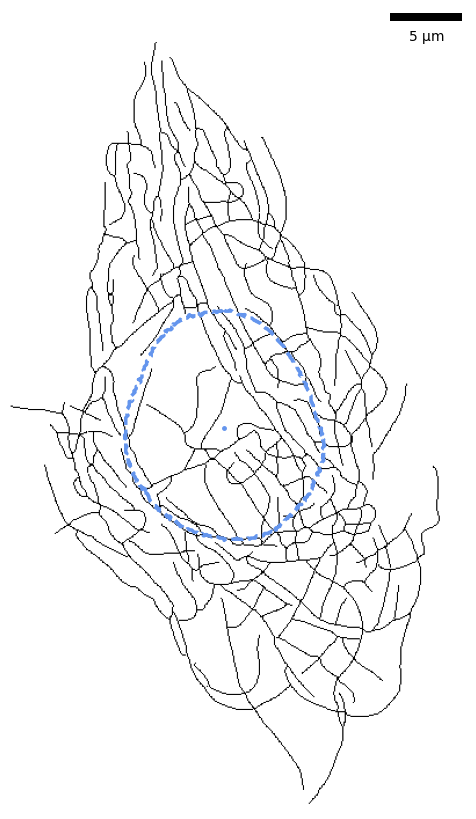

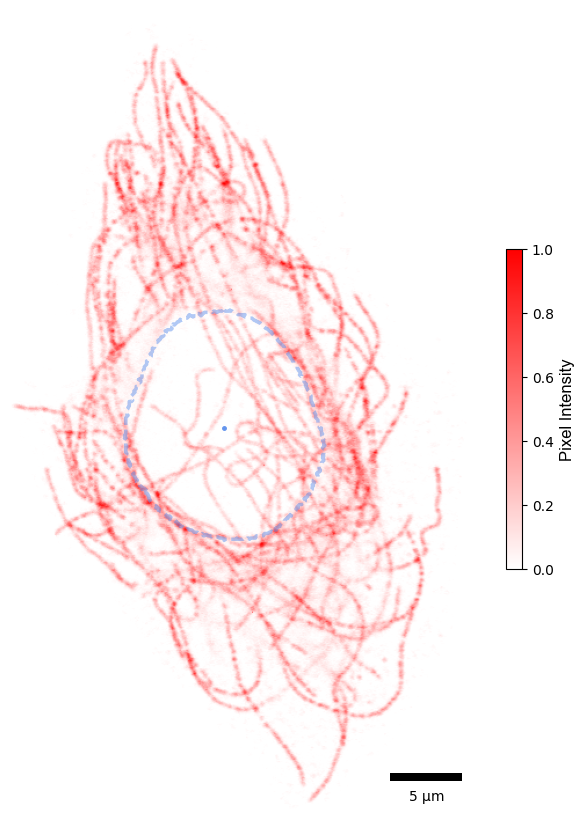

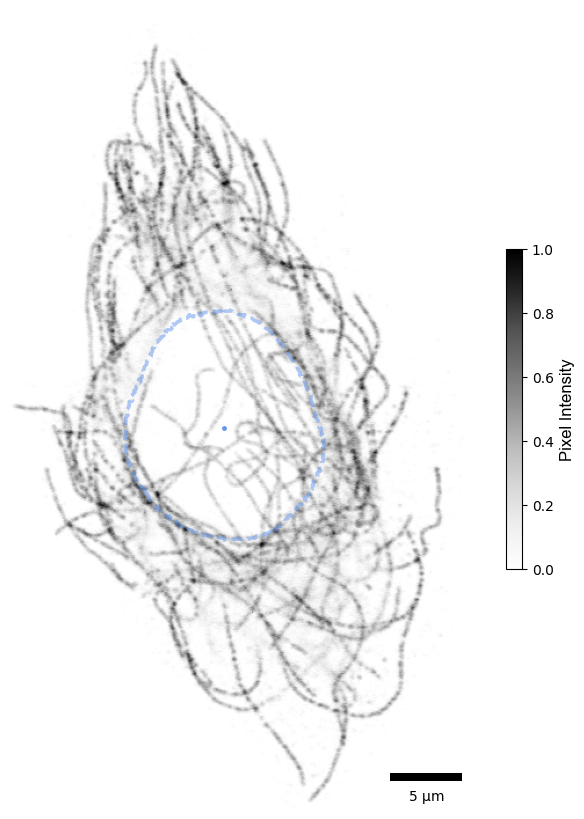

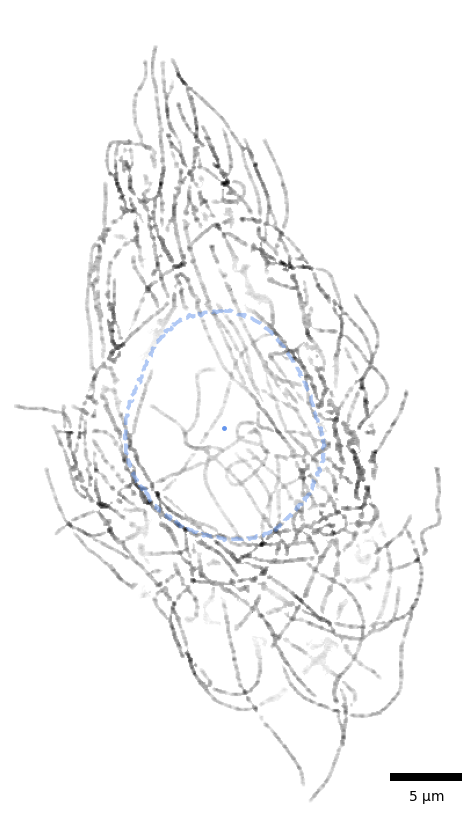

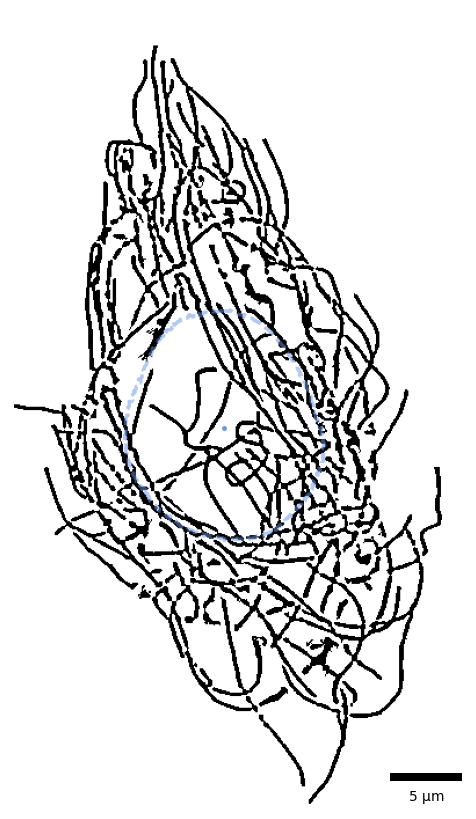

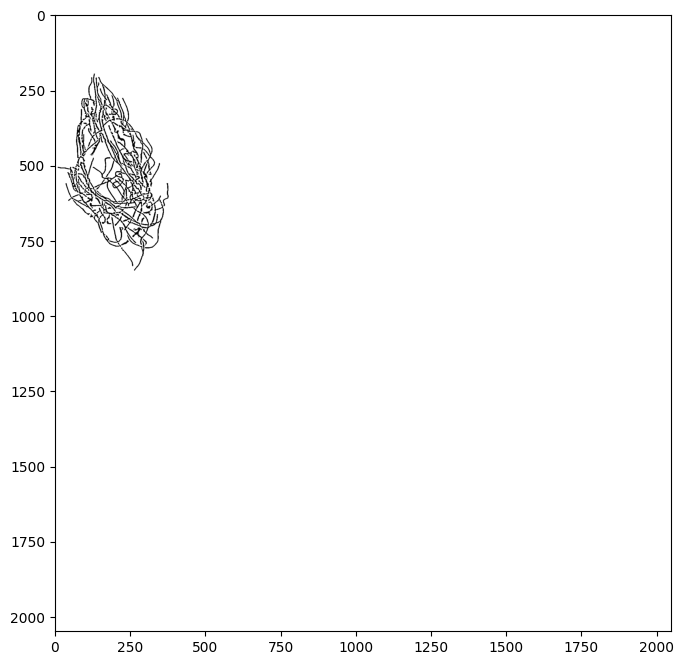

In [10]:
fig_int = intensity_plotter(ResultsRow = ResultsDF.loc[cell],
                            data       = data,
                            save       = False)  

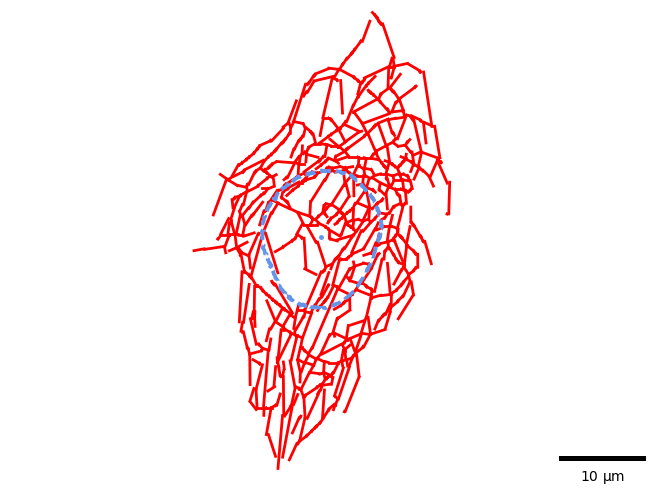

In [11]:
cmap     = pltc.rainbow
cm       = truncate_colormap(cmap, 0, 1, 300)

fig_lines = line_plotter(ResultsRow = ResultsDF.loc[0],
                                 data=data,
                                 feat=None,
                                 cmap=cm,
                                 normalize_bounds=1,
                                 colorbar_label=None,
                                 overlay=True,
                                 save=False)

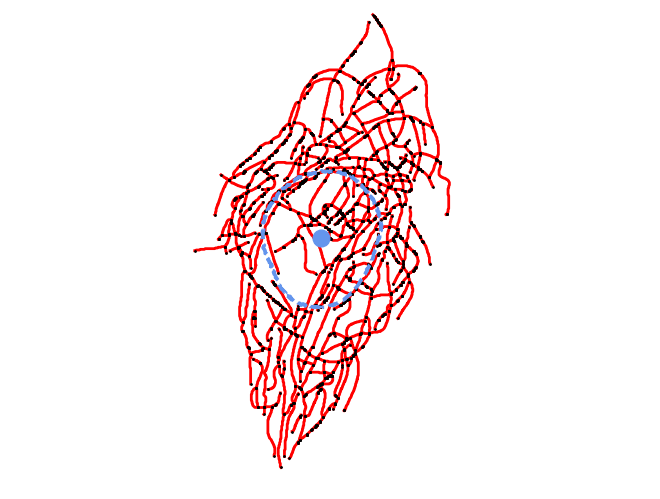

In [12]:
cmap     = pltc.rainbow
cm       = truncate_colormap(cmap, 0, 1, 300)

fig_graph = graph_plotter(ResultsRow       = ResultsDF.loc[0],
                          data             = data,
                          feat             = None,
                          cmap             = cm,
                          normalize_bounds = 'default',
                          colorbar_label   = None,
                          nodes            = True,
                          main_branch      = False,
                          overlay          = None,
                          scalebar         = False,
                          save             = False)

# Post processing

Get SOAX post-processing

In [13]:
filament_dataframes,junctionsdf = read_soax_txt('snakes_june2.txt')

In [8]:
filament_dataframes,junctionsdf = read_soax_txt('snakes1.txt')

Filament DataFrames:
Filament 1:
Empty DataFrame
Columns: [s, p, x, y, z, fg_int, bg_int]
Index: [] 

Filament 2:
     s    p        x        y  z     fg_int    bg_int
0    0    0  122.793  313.022  0    1.16119   0.00000
1    0    1  122.334  313.912  0  154.79000   0.00000
2    0    2  121.871  314.799  0  221.99600   0.00000
3    0    3  121.418  315.692  0  135.51500   0.00000
4    0    4  120.968  316.587  0  246.88300   0.00000
..  ..  ...      ...      ... ..        ...       ...
191  0  191  188.219  456.457  0  133.60800   0.00000
192  0  192  189.115  456.904  0  230.54500   0.00000
193  0  193  189.994  457.384  0  156.99500   9.38703
194  0  194  190.864  457.880  0  197.91100  13.46070
195  0  195  191.725  458.391  0   42.79170  21.91150

[196 rows x 7 columns] 

Filament 3:
     s    p        x        y  z   fg_int    bg_int
0    1    0  112.414  413.847  0  165.663  76.36570
1    1    1  113.348  413.496  0  128.475   8.41376
2    1    2  114.312  413.240  0  193.749   

      s   p        x        y  z     fg_int     bg_int
0   117   0  131.035  495.418  0    5.21276   0.705883
1   117   1  131.942  494.951  0  228.42700   0.000000
2   117   2  132.875  494.540  0  119.79500   0.000000
3   117   3  133.851  494.247  0  191.94000   9.819580
4   117   4  134.840  493.998  0  254.45800  18.717900
5   117   5  135.775  493.591  0  231.47700  23.935800
6   117   6  136.587  492.975  0  106.49000  27.537500
7   117   7  137.356  492.306  0  177.07500  19.767900
8   117   8  138.119  491.629  0  152.58500  16.097300
9   117   9  138.888  490.960  0  217.52500  30.015400
10  117  10  139.625  490.255  0  143.06200  19.240000
11  117  11  140.328  489.517  0  129.03000  28.655300
12  117  12  141.004  488.754  0  191.68000  14.111100
13  117  13  141.641  487.958  0  163.51400  38.508000
14  117  14  142.249  487.139  0  191.61900  48.259600
15  117  15  142.768  486.262  0  160.07200  19.220200
16  117  16  143.119  485.305  0  245.77900   5.944700 

Filament

      s   p        x        y  z      fg_int    bg_int
0   199   0  256.800  335.042  0    8.476480   0.00000
1   199   1  256.880  336.033  0  224.415000   0.00000
2   199   2  256.938  337.025  0  239.306000   0.00000
3   199   3  257.001  338.017  0  254.748000   0.00000
4   199   4  257.163  338.999  0  213.519000   0.00000
5   199   5  257.516  339.928  0  123.433000   0.00000
6   199   6  258.050  340.767  0  185.801000   0.00000
7   199   7  258.643  341.565  0  132.209000   0.00000
8   199   8  259.129  342.432  0  240.764000   2.15623
9   199   9  259.312  343.409  0  175.366000  33.82460
10  199  10  259.384  344.401  0  157.095000   0.00000
11  199  11  259.570  345.377  0  123.097000   0.00000
12  199  12  259.905  346.314  0  230.814000   0.00000
13  199  13  260.335  347.210  0  151.861000   0.00000
14  199  14  260.799  348.090  0  203.699000   0.00000
15  199  15  261.318  348.937  0  173.866000   0.00000
16  199  16  261.893  349.749  0  177.351000   0.00000
17  199  1

In [5]:
filament_dataframes

[    s   p        x        y  z    fg_int    bg_int
 0   0   0  116.330  396.287  0  39014.70      0.00
 1   0   1  117.328  396.350  0  36672.50   1515.12
 2   0   2  118.317  396.204  0  23716.60  12949.60
 3   0   3  119.308  396.068  0  26184.10   1706.51
 4   0   4  120.306  396.011  0  26699.00      0.00
 .. ..  ..      ...      ... ..       ...       ...
 57  0  57  162.027  368.267  0   9672.54      0.00
 58  0  58  162.648  367.483  0   4487.97      0.00
 59  0  59  163.368  366.789  0   4610.56      0.00
 60  0  60  164.159  366.178  0   9654.24   1574.06
 61  0  61  164.944  365.558  0   6569.04   4180.83
 
 [62 rows x 7 columns],
     s   p        x        y  z   fg_int     bg_int
 0   1   0  155.452  380.056  0  19212.9    38.0994
 1   1   1  156.453  380.023  0  19152.7   842.7800
 2   1   2  157.454  380.034  0  12189.2  2418.9700
 3   1   3  158.456  380.036  0  10006.0  2234.6400
 4   1   4  159.456  379.989  0  12082.4  1214.4100
 .. ..  ..      ...      ... ..      .

In [11]:
junctionsdf

,x,y,z
0,65.2755,318.388,0
1,69.1986,338.273,0
2,75.8479,349.001,0
3,78.1301,373.851,0
4,75.5789,446.850,0
...,...,...,...
267,105.0420,273.503,0
268,135.5500,453.890,0
269,81.9930,305.110,0
270,223.7720,487.279,0


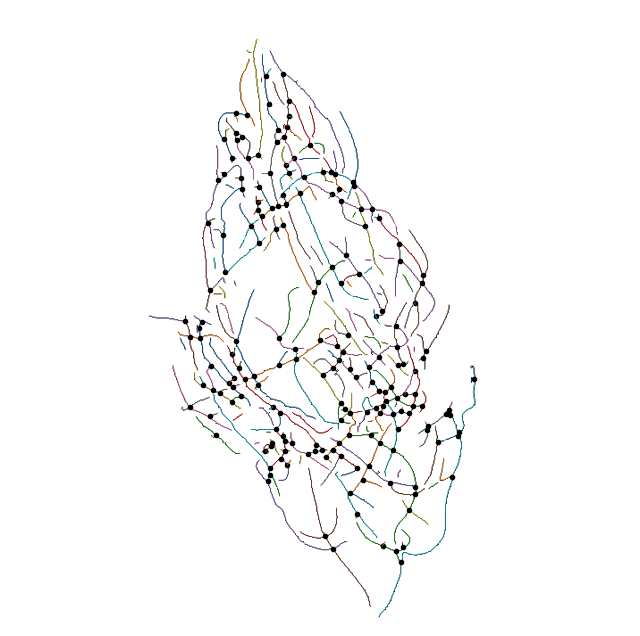

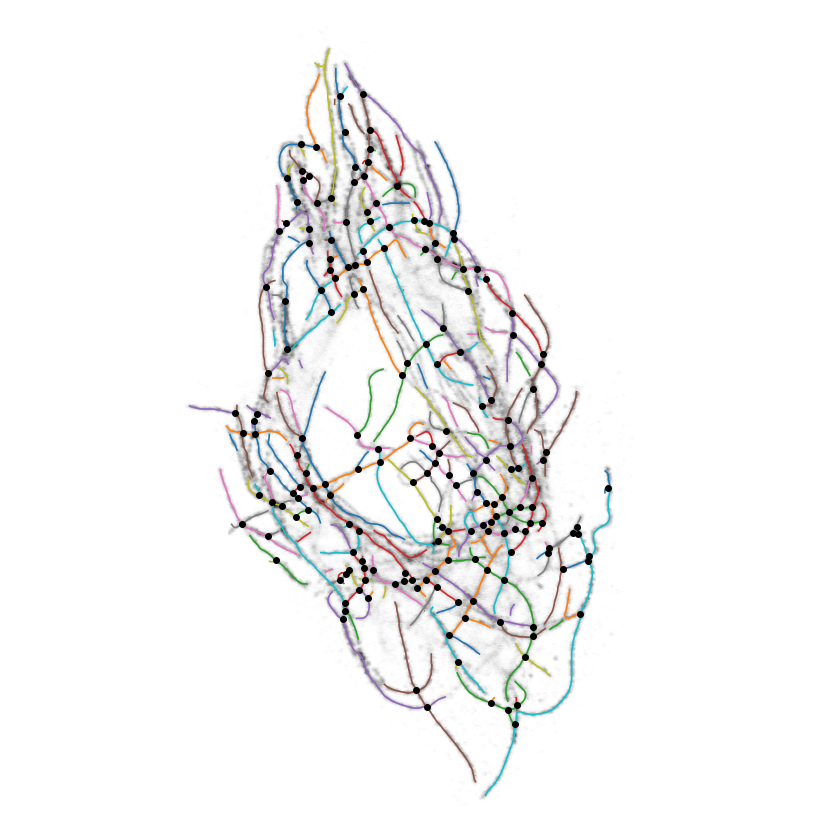

In [9]:

                    

#plot_soax(np.max(imagens[0]) - imagens[0][180:860,0:400],skelorig,filament_dataframes,junctionsdf)
fig1,fig2 = plot_soax_filaments(imgorig             = ResultsDF.loc[cell]['Patch:Deconvoluted Cyto'],
                      skel                = ResultsDF.loc[cell]['Patch:Skeleton'],
                      filament_df         = filament_dataframes,
                      junctionsdf         = junctionsdf)
    
    
    
    #np.max(imagens[0]) - imagens[0][180:860,0:400],skelorig,filament_dataframes,junctionsdf)

In [11]:
sk = getske(ResultsRow = ResultsDF.loc[0],data=data)

In [15]:
sk.path_coordinates(0)

array([[198., 130.],
       [199., 130.],
       [200., 130.],
       [201., 129.],
       [202., 129.],
       [203., 129.],
       [204., 129.],
       [205., 128.],
       [206., 128.],
       [207., 128.],
       [208., 128.],
       [209., 127.],
       [210., 127.],
       [211., 127.],
       [212., 127.],
       [213., 127.],
       [214., 127.],
       [215., 127.],
       [216., 127.],
       [217., 127.],
       [218., 127.],
       [219., 127.],
       [220., 127.],
       [221., 128.],
       [222., 128.],
       [223., 128.],
       [224., 128.],
       [225., 129.],
       [226., 129.],
       [227., 129.],
       [228., 129.],
       [229., 130.],
       [230., 130.],
       [231., 130.],
       [232., 130.],
       [233., 130.],
       [234., 130.],
       [235., 130.],
       [236., 130.],
       [237., 130.],
       [238., 130.],
       [239., 130.],
       [240., 131.],
       [241., 131.],
       [242., 131.],
       [243., 131.],
       [244., 131.],
       [245.,

In [56]:
path_coordinates = [np.array([list(zip(r['x'],r['y']))]) for r in filament_dataframes]

In [57]:
path_coordinates[0]

array([[[116.33 , 396.287],
        [117.328, 396.35 ],
        [118.317, 396.204],
        [119.308, 396.068],
        [120.306, 396.011],
        [121.306, 395.992],
        [122.305, 395.955],
        [123.299, 395.841],
        [124.268, 395.595],
        [125.19 , 395.208],
        [126.018, 394.647],
        [126.666, 393.886],
        [127.333, 393.141],
        [128.197, 392.638],
        [129.167, 392.397],
        [130.143, 392.179],
        [131.086, 391.845],
        [131.996, 391.431],
        [132.936, 391.089],
        [133.883, 390.769],
        [134.826, 390.435],
        [135.781, 390.141],
        [136.714, 389.781],
        [137.572, 389.268],
        [138.313, 388.597],
        [139.032, 387.902],
        [139.884, 387.377],
        [140.822, 387.033],
        [141.772, 386.719],
        [142.698, 386.341],
        [143.604, 385.92 ],
        [144.522, 385.523],
        [145.475, 385.22 ],
        [146.462, 385.058],
        [147.459, 384.98 ],
        [148.45 , 38

In [7]:
data['filaments'],data['junctions'] = read_soax_txt('snakes_june2.txt')

Filament DataFrames:
Filament 1:
Empty DataFrame
Columns: [s, p, x, y, z, fg_int, bg_int]
Index: [] 

Filament 2:
    s   p        x        y  z    fg_int    bg_int
0   0   0  116.330  396.287  0  39014.70      0.00
1   0   1  117.328  396.350  0  36672.50   1515.12
2   0   2  118.317  396.204  0  23716.60  12949.60
3   0   3  119.308  396.068  0  26184.10   1706.51
4   0   4  120.306  396.011  0  26699.00      0.00
.. ..  ..      ...      ... ..       ...       ...
57  0  57  162.027  368.267  0   9672.54      0.00
58  0  58  162.648  367.483  0   4487.97      0.00
59  0  59  163.368  366.789  0   4610.56      0.00
60  0  60  164.159  366.178  0   9654.24   1574.06
61  0  61  164.944  365.558  0   6569.04   4180.83

[62 rows x 7 columns] 

Filament 3:
    s   p        x        y  z   fg_int     bg_int
0   1   0  155.452  380.056  0  19212.9    38.0994
1   1   1  156.453  380.023  0  19152.7   842.7800
2   1   2  157.454  380.034  0  12189.2  2418.9700
3   1   3  158.456  380.036  0  1

     s   p        x        y  z    fg_int    bg_int
0   20   0  311.002  390.156  0  28861.10  4748.050
1   20   1  310.985  391.159  0  25268.50  5159.830
2   20   2  310.966  392.162  0  21734.70  5882.180
3   20   3  310.962  393.165  0  20031.00  5638.620
4   20   4  311.051  394.165  0  28064.30  4484.320
..  ..  ..      ...      ... ..       ...       ...
67  20  67  291.818  450.459  0   6073.44     0.000
68  20  68  291.023  451.071  0  10343.80   813.677
69  20  69  290.248  451.708  0  11475.60  2956.950
70  20  70  289.447  452.312  0  10782.50  4039.890
71  20  71  288.660  452.935  0  25693.20   408.641

[72 rows x 7 columns] 

Filament 23:
      s    p        x        y  z    fg_int    bg_int
0    21    0  294.984  590.896  0  27427.10  8280.380
1    21    1  295.960  591.124  0  17553.40  4288.340
2    21    2  296.943  591.315  0   7673.90   704.632
3    21    3  297.925  591.515  0   2961.96     0.000
4    21    4  298.893  591.773  0   7776.93     0.000
..   ..  ...  

      s    p         x        y  z    fg_int    bg_int
0    39    0   42.0882  342.983  0      0.00     0.000
1    39    1   42.7298  343.746  0   7537.03     0.000
2    39    2   43.3364  344.537  0   6813.38     0.000
3    39    3   43.8929  345.363  0  12051.20     0.000
4    39    4   44.5332  346.127  0   6131.74     0.000
..   ..  ...       ...      ... ..       ...       ...
104  39  104  109.3420  411.246  0   6341.00     0.000
105  39  105  110.1490  411.832  0   7838.23   536.549
106  39  106  110.9870  412.371  0   4382.38  1091.140
107  39  107  111.8220  412.914  0   6566.92  1449.320
108  39  108  112.6400  413.483  0   1597.79  1318.880

[109 rows x 7 columns] 

Filament 42:
      s    p        x         y  z    fg_int    bg_int
0    40    0  217.917  166.6930  0  17324.40   386.076
1    40    1  218.854  166.3350  0  17498.70   763.030
2    40    2  219.832  166.1160  0  24783.90  7947.810
3    40    3  220.824  166.2640  0  19124.10  3285.830
4    40    4  221.751  166

     s   p        x        y  z    fg_int     bg_int
0   56   0  162.704  203.867  0  10781.10  2440.1700
1   56   1  163.316  203.079  0  14074.80     1.6741
2   56   2  163.733  202.173  0  14707.70     0.0000
3   56   3  163.939  201.196  0  22000.10     0.0000
4   56   4  163.945  200.199  0  25246.40     0.0000
5   56   5  163.746  199.221  0  15770.80     0.0000
6   56   6  163.437  198.272  0   7672.42   564.0490
7   56   7  163.131  197.322  0  11025.80   810.0910
8   56   8  162.814  196.376  0  11530.00   538.5250
9   56   9  162.443  195.450  0   6606.51     0.0000
10  56  10  162.029  194.542  0  10585.30     0.0000
11  56  11  161.641  193.622  0   5426.53     0.0000
12  56  12  161.321  192.677  0   9993.41    88.2759
13  56  13  161.059  191.715  0  21711.50  1034.7200
14  56  14  160.786  190.755  0  20949.30     0.0000
15  56  15  160.556  189.784  0  28470.80     0.0000 

Filament 59:
     s   p        x        y  z    fg_int     bg_int
0   57   0  156.628  193.493  0

     s   p        x        y  z    fg_int    bg_int
0   84   0  251.683  348.720  0   3303.13  2525.260
1   84   1  252.665  348.870  0   5497.99  2457.080
2   84   2  253.644  349.034  0   7423.34  1769.060
3   84   3  254.611  349.259  0   6013.39   649.931
4   84   4  255.558  349.558  0   7123.38   247.955
5   84   5  256.515  349.820  0  15280.90     0.000
6   84   6  257.498  349.960  0  17333.50   217.087
7   84   7  258.491  349.992  0  15011.20  1215.650
8   84   8  259.484  349.987  0  13648.50  1921.370
9   84   9  260.476  350.020  0  13552.20  1207.170
10  84  10  261.454  350.192  0  11347.40     0.000
11  84  11  262.369  350.578  0   6838.66     0.000
12  84  12  263.168  351.166  0   9671.94     0.000
13  84  13  263.889  351.849  0  11187.80     0.000
14  84  14  264.588  352.554  0   7342.67     0.000
15  84  15  265.283  353.263  0   8682.47     0.000
16  84  16  265.957  353.993  0  14079.10     0.000
17  84  17  266.565  354.777  0   9958.91     0.000
18  84  18  

      s   p        x        y  z    fg_int     bg_int
0   107   0  311.978  457.984  0      0.00     0.0000
1   107   1  312.693  457.280  0   6943.92     0.0000
2   107   2  313.411  456.578  0   6498.49     0.0000
3   107   3  314.146  455.894  0   7879.16     0.0000
4   107   4  314.924  455.259  0   5577.22     0.0000
5   107   5  315.750  454.688  0   3297.16     0.0000
6   107   6  316.607  454.164  0   1227.13     0.0000
7   107   7  317.469  453.649  0   2165.20     0.0000
8   107   8  318.341  453.151  0   9848.80  1485.0400
9   107   9  319.226  452.678  0   9902.74  2614.0700
10  107  10  320.172  452.342  0  12273.00   894.7750
11  107  11  321.175  452.393  0  15925.10   377.7670
12  107  12  321.866  453.120  0  14865.80    10.7285
13  107  13  322.086  454.099  0  11845.10  1290.2900
14  107  14  322.114  455.103  0   7670.23  1192.4700
15  107  15  322.089  456.106  0   6241.92    78.1872
16  107  16  322.065  457.110  0   7926.19     0.0000
17  107  17  322.051  458.11

      s   p        x        y  z    fg_int    bg_int
0   134   0  136.912  32.0158  0    134.17     0.000
1   134   1  136.951  33.0129  0   8881.39     0.000
2   134   2  136.982  34.0102  0  11537.40     0.000
3   134   3  136.999  35.0079  0  13438.60     0.000
4   134   4  137.003  36.0057  0  17227.40     0.000
..  ...  ..      ...      ... ..       ...       ...
57  134  57  144.861  87.6754  0  15757.30   322.255
58  134  58  145.674  88.2535  0  17011.00  5893.330
59  134  59  146.480  88.8425  0  10948.20  6007.890
60  134  60  147.142  89.5888  0  17965.30  4762.230
61  134  61  147.724  90.3993  0   3305.51  1792.240

[62 rows x 7 columns] 

Filament 137:
     s  p        x        y  z    fg_int   bg_int
0  135  0  175.101  362.000  0  14968.30  4682.03
1  135  1  176.054  362.000  0  18267.80  1380.14
2  135  2  177.007  362.000  0  14465.40     0.00
3  135  3  177.960  362.000  0  12580.50     0.00
4  135  4  178.913  362.001  0   9527.40     0.00
5  135  5  179.866  361.9

      s   p         x        y  z     fg_int     bg_int
0   159   0   89.3154  311.440  0   1618.160  1180.3400
1   159   1   90.2554  311.770  0   8546.930    95.5746
2   159   2   91.1970  312.095  0   8597.370     0.0000
3   159   3   92.1204  312.469  0   5116.640     0.0000
4   159   4   92.9858  312.963  0  10041.800     0.0000
5   159   5   93.8235  313.502  0   5773.210     0.0000
6   159   6   94.6498  314.059  0  12431.900     0.0000
7   159   7   95.3970  314.718  0   7262.640     0.0000
8   159   8   95.9404  315.553  0  12770.500     0.0000
9   159   9   96.3017  316.481  0   6019.550     0.0000
10  159  10   96.6067  317.430  0   3045.200     0.0000
11  159  11   96.9487  318.365  0   6870.380     0.0000
12  159  12   97.3249  319.288  0   4949.150     0.0000
13  159  13   97.6855  320.217  0   4591.770     0.0000
14  159  14   97.9888  321.166  0   7725.500     0.0000
15  159  15   98.2694  322.121  0   5982.690     0.0000
16  159  16   98.5465  323.078  0    566.662    

     s  p        x        y  z    fg_int  bg_int
0  179  0  254.985  444.636  0      0.00       0
1  179  1  255.886  444.340  0   9049.27       0
2  179  2  256.809  444.124  0  12169.70       0
3  179  3  257.744  443.967  0  13158.30       0
4  179  4  258.664  443.733  0  10243.30       0
5  179  5  259.522  443.331  0   7175.39       0
6  179  6  260.296  442.782  0   7781.17       0
7  179  7  261.030  442.181  0      0.00       0 

Filament 182:
      s   p        x         y  z    fg_int     bg_int
0   180   0  189.397   90.2364  0   1848.73  1025.4500
1   180   1  189.739   91.1869  0  15405.50  2009.5600
2   180   2  190.075   92.1397  0  22617.00  3248.2500
3   180   3  190.400   93.0963  0   9399.95  2816.1700
4   180   4  190.730   94.0510  0  12090.40  2788.1600
5   180   5  190.952   95.0365  0  13499.50   623.2500
6   180   6  191.125   96.0318  0  13495.00     0.0000
7   180   7  191.379   97.0096  0   7021.31    16.2412
8   180   8  191.734   97.9554  0  11484.00     

      s   p        x        y  z    fg_int   bg_int
0   205   0  241.612  395.450  0   5899.23  4459.57
1   205   1  242.006  396.382  0  20407.60     0.00
2   205   2  242.496  397.267  0   8407.39     0.00
3   205   3  243.066  398.103  0   8598.78     0.00
4   205   4  243.649  398.929  0   6483.28     0.00
5   205   5  244.208  399.773  0   7509.88     0.00
6   205   6  244.744  400.630  0   4212.23     0.00
7   205   7  245.278  401.489  0   3418.10     0.00
8   205   8  245.806  402.352  0   5920.06     0.00
9   205   9  246.378  403.186  0   6248.01     0.00
10  205  10  247.016  403.971  0  15120.00     0.00
11  205  11  247.692  404.724  0   9168.95     0.00
12  205  12  248.341  405.500  0   7011.34     0.00
13  205  13  248.923  406.327  0   9719.88     0.00
14  205  14  249.485  407.168  0   4160.72     0.00
15  205  15  250.045  408.010  0      0.00     0.00 

Filament 208:
      s   p        x        y  z      fg_int      bg_int
0   206   0  268.106  291.007  0     13.562

<div class="alert alert-block alert-info">
    
 **SAVE DATAFRAME FOR FEATURE EXTRACTION**
    
</div>

In [9]:
ResultsDF.to_pickle(folder + '//ResultsDF_TEST_FINAL.pkl')   

---